In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('raw_leads.csv')

In [ ]:
df.shape

(7210, 11)

In [ ]:
df.dtypes

,0
lead_id,object
created_date,object
lead_source,object
product_line,object
region,object
nam_owner,object
client_type,object
deal_value_usd,float64
period,object
lead_status,object


In [ ]:
df['created_date'] = pd.to_datetime(df['created_date'],format='mixed',dayfirst=False)

In [ ]:
df.loc[df['lead_id'] == 'L-P1-00011','created_date']

,created_date
10,2024-12-24


In [ ]:
df['lead_source'] = df['lead_source'].str.strip().str.title()

In [ ]:
df['lead_source'].unique()

array(['Cold Outreach', 'Partner Referral', 'Trade Show',
       'Inbound Web Form', 'Existing Client Upsell', 'Outbound Sdr'],
      dtype=object)

In [ ]:
# s = df['stage'].str.lower()

In [ ]:
# conditions = [s.str.contains('qualified'), s.str.contains('lead'), s.str.contains('won'), s.str.contains('lost')]
# choices = ['qualified', 'lead', 'won', 'lost']

# df['stage'] = np.select(conditions, choices, default = df['stage'])

In [ ]:
# df['stage'].value_counts()

In [ ]:
df['region'].unique()

array(['Midwest', 'West', 'NORTHEAST', 'South', 'Northeast', nan, 'SOUTH',
       'WEST', 'MIDWEST'], dtype=object)

In [ ]:
df['region'] = df['region'].str.strip().str.title()

In [ ]:
df['region'].unique()

array(['Midwest', 'West', 'Northeast', 'South', nan], dtype=object)

In [ ]:
df.isna().sum()

,0
lead_id,0
created_date,0
lead_source,0
product_line,0
region,144
nam_owner,108
client_type,0
deal_value_usd,72
period,0
lead_status,0


In [ ]:
df['created_date'] = df['created_date'].dt.date

In [ ]:
# df['stage_date'] = df['stage_date'].dt.date

In [ ]:
# df.drop(df[df['created_date'] > df['stage_date']].index, inplace=True)

In [ ]:
df.shape

(7210, 11)

In [ ]:
df.describe(include='all')

,lead_id,created_date,lead_source,product_line,region,nam_owner,client_type,deal_value_usd,period,lead_status,disqualified_reason
count,7210,7210,7210,7210,7066,7102,7210,7138.000000,7210,7210,2235
unique,7210,666,6,5,4,8,5,NaN,2,3,4
top,L-P1-01003-DUP,2025-02-25,Inbound Web Form,Smart Lighting,South,M. Okafor,Campus,NaN,P2,Open,No response
freq,1,26,2021,1472,1818,909,1468,NaN,3698,3214,596
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33408.330625,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24524.357404,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-999.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17503.750000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26998.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41964.500000,NaN,NaN,NaN


In [ ]:
df['region'] = df['region'].fillna('Unknown')

In [ ]:
df['region'].unique()

array(['Midwest', 'West', 'Northeast', 'South', 'Unknown'], dtype=object)

In [ ]:
df.isna().sum()

,0
lead_id,0
created_date,0
lead_source,0
product_line,0
region,0
nam_owner,108
client_type,0
deal_value_usd,72
period,0
lead_status,0


In [ ]:
df['nam_owner'] = df['nam_owner'].fillna('Unassigned')

In [ ]:
df.nam_owner.unique()

array(['J. Sullivan', 'D. Singh', 'S. Patel', 'R. Alvarez', 'M. Okafor',
       'L. Fitzgerald', 'K. Romano', 'T. Chen', 'Unassigned'],
      dtype=object)

In [ ]:
df.groupby('lead_id').agg(total_count = ('lead_id', 'size')).query('total_count > 1')

,total_count
lead_id,


In [ ]:
df[df['lead_id'].str.lower().str.contains('dup')].index

Index([7000, 7001, 7002, 7003, 7004, 7005, 7006, 7007, 7008, 7009,
       ...
       7200, 7201, 7202, 7203, 7204, 7205, 7206, 7207, 7208, 7209],
      dtype='int64', length=210)

In [ ]:
df.drop(df[df['lead_id'].str.lower().str.contains('dup')].index,inplace=True)

In [ ]:
df.shape

(7000, 11)

In [ ]:
df.isna().sum()

,0
lead_id,0
created_date,0
lead_source,0
product_line,0
region,0
nam_owner,0
client_type,0
deal_value_usd,68
period,0
lead_status,0


In [ ]:
import matplotlib.pyplot as plt

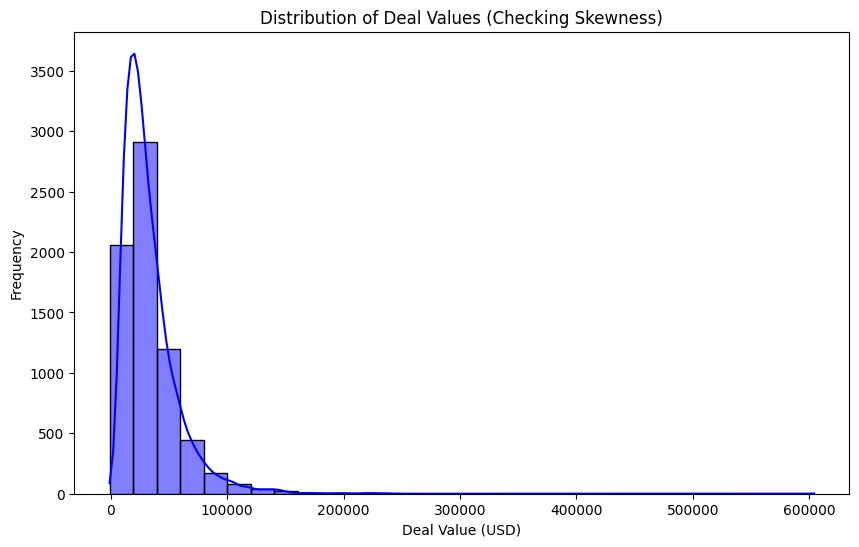

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the size of the graph
plt.figure(figsize=(10, 6))

# Create a histogram with a Kernel Density Estimate (KDE) curve
sns.histplot(df['deal_value_usd'], kde=True, bins=30, color='blue')

# Add labels
plt.title('Distribution of Deal Values (Checking Skewness)')
plt.xlabel('Deal Value (USD)')
plt.ylabel('Frequency')

plt.show()

<Axes: xlabel='client_type', ylabel='deal_value_usd'>

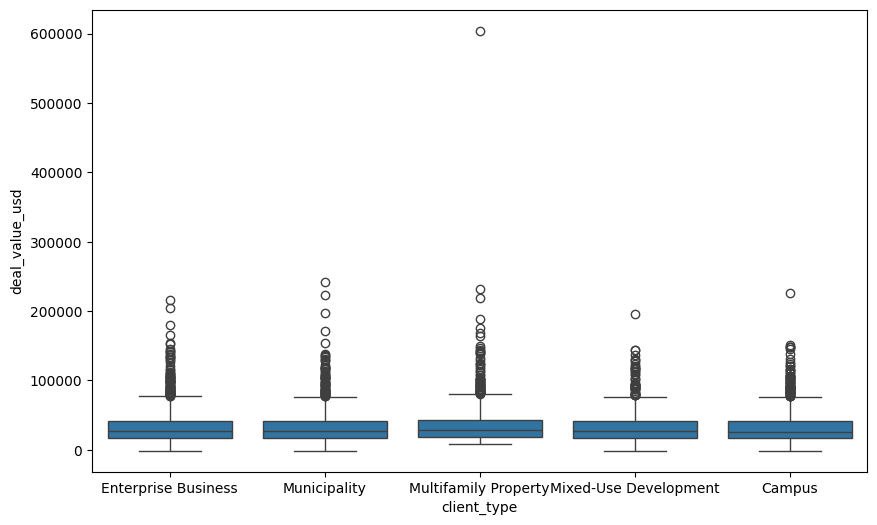

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df,x='client_type',y='deal_value_usd')


In [ ]:
df[df['deal_value_usd'] < 0]

,lead_id,created_date,lead_source,product_line,region,nam_owner,client_type,deal_value_usd,period,lead_status,disqualified_reason
674,L-P1-00675,2024-01-12,Outbound Sdr,Video Analytics,West,K. Romano,Campus,-999.0,P1,Open,NaN
4698,L-P2-01299,2025-07-17,Inbound Web Form,Smart Buildings,Midwest,K. Romano,Municipality,-999.0,P2,Open,NaN
5454,L-P2-02055,2025-01-13,Partner Referral,Video Analytics,Midwest,L. Fitzgerald,Mixed-Use Development,-999.0,P2,Open,NaN
5844,L-P2-02445,2025-06-01,Trade Show,Smart Mobility (EV/Parking),Northeast,T. Chen,Enterprise Business,-999.0,P2,Disqualified,No budget
6159,L-P2-02760,2025-08-06,Cold Outreach,Smart Mobility (EV/Parking),West,T. Chen,Enterprise Business,-999.0,P2,Disqualified,No budget


In [ ]:
Q1 = df['deal_value_usd'].quantile(0.25)
Q2 = df['deal_value_usd'].quantile(0.5)
Q3 = df['deal_value_usd'].quantile(0.75)
IQR= Q3 - Q1

In [ ]:
print(f"Q1: {Q1}, Q2: {Q2}, Q3: {Q3}, IQR: {IQR}")

Q1: 17555.75, Q2: 27056.0, Q3: 41963.5, IQR: 24407.75


In [ ]:
median_value = df.loc[df['deal_value_usd'] > 0, 'deal_value_usd'].median()

In [ ]:
print(median_value)

27082.0


In [ ]:
df.loc[df['deal_value_usd'] < 0, 'deal_value_usd'] = np.nan

In [ ]:
df.groupby(['client_type', 'product_line'])['deal_value_usd'].median()

client_type            product_line               
Campus                 Digital Signage                25882.5
                       Smart Buildings                25297.5
                       Smart Lighting                 27658.0
                       Smart Mobility (EV/Parking)    29051.0
                       Video Analytics                25614.0
Enterprise Business    Digital Signage                26122.0
                       Smart Buildings                26807.0
                       Smart Lighting                 27536.0
                       Smart Mobility (EV/Parking)    29139.0
                       Video Analytics                28353.0
Mixed-Use Development  Digital Signage                25873.5
                       Smart Buildings                27702.0
                       Smart Lighting                 26333.0
                       Smart Mobility (EV/Parking)    28331.0
                       Video Analytics                24940.0
Multifamily Property   Digital Signage                28178.0
                       Smart Buildings                27969.5
                       Smart Lighting                 29742.0
                       Smart Mobility (EV/Parking)    29576.0
                       Video Analytics                26663.0
Municipality           Digital Signage                26180.5
                       Smart Buildings                26156.0
                       Smart Lighting                 27142.0
                       Smart Mobility (EV/Parking)    27796.0
                       Video Analytics                27634.0
Name: deal_value_usd, dtype: float64

In [ ]:
median_value = df.loc[df['deal_value_usd'] > 0, 'deal_value_usd'].median()
print(median_value)

27082.0


In [ ]:
df['deal_value_usd'] = df['deal_value_usd'].fillna(df.groupby(['client_type', 'product_line'])['deal_value_usd'].transform(lambda x: x.median()))

In [ ]:
df.isna().sum()

,0
lead_id,0
created_date,0
lead_source,0
product_line,0
region,0
nam_owner,0
client_type,0
deal_value_usd,0
period,0
lead_status,0


In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"lower_bound: {lower_bound}, upper_bound: {upper_bound}")

lower_bound: -19055.875, upper_bound: 78575.125


In [ ]:
df['is_deal_value_outlier'] = np.where((df['deal_value_usd'] > upper_bound) | (df['deal_value_usd'] < lower_bound), True, False)

In [ ]:
df[df['is_deal_value_outlier']]

,lead_id,created_date,lead_source,product_line,region,nam_owner,client_type,deal_value_usd,period,lead_status,disqualified_reason,is_deal_value_outlier
10,L-P1-00011,2024-12-24,Outbound Sdr,Smart Mobility (EV/Parking),South,J. Sullivan,Multifamily Property,78959.0,P1,Qualified,NaN,True
12,L-P1-00013,2024-09-03,Inbound Web Form,Smart Mobility (EV/Parking),Northeast,J. Sullivan,Multifamily Property,79473.0,P1,Open,NaN,True
62,L-P1-00063,2024-07-07,Inbound Web Form,Video Analytics,Northeast,M. Okafor,Campus,130291.0,P1,Qualified,NaN,True
85,L-P1-00086,2024-12-15,Cold Outreach,Smart Buildings,Midwest,J. Sullivan,Municipality,223678.0,P1,Qualified,NaN,True
107,L-P1-00108,2024-01-07,Inbound Web Form,Smart Buildings,South,M. Okafor,Enterprise Business,129327.0,P1,Disqualified,Wrong fit,True
...,...,...,...,...,...,...,...,...,...,...,...,...
6916,L-P2-03517,2025-05-10,Outbound Sdr,Digital Signage,South,K. Romano,Municipality,136449.0,P2,Disqualified,No budget,True
6954,L-P2-03555,2025-08-04,Outbound Sdr,Smart Lighting,Northeast,M. Okafor,Enterprise Business,92014.0,P2,Disqualified,No budget,True
6957,L-P2-03558,2025-08-14,Outbound Sdr,Smart Mobility (EV/Parking),Midwest,K. Romano,Campus,138816.0,P2,Open,NaN,True
6958,L-P2-03559,2025-02-13,Partner Referral,Smart Buildings,West,R. Alvarez,Enterprise Business,88460.0,P2,Disqualified,No response,True


In [ ]:
df.head()

,lead_id,created_date,lead_source,product_line,region,nam_owner,client_type,deal_value_usd,period,lead_status,disqualified_reason,is_deal_value_outlier
0,L-P1-00001,2024-02-16,Cold Outreach,Smart Buildings,Midwest,J. Sullivan,Enterprise Business,9363.0,P1,Open,NaN,False
1,L-P1-00002,2024-04-04,Partner Referral,Smart Mobility (EV/Parking),West,D. Singh,Municipality,25180.0,P1,Qualified,NaN,False
2,L-P1-00003,2024-09-14,Partner Referral,Smart Lighting,Northeast,J. Sullivan,Enterprise Business,8296.0,P1,Qualified,NaN,False
3,L-P1-00004,2024-04-28,Trade Show,Video Analytics,West,S. Patel,Enterprise Business,31911.0,P1,Qualified,NaN,False
4,L-P1-00005,2024-07-12,Inbound Web Form,Digital Signage,West,S. Patel,Multifamily Property,31855.0,P1,Disqualified,No response,False


In [ ]:
df.to_csv('leads_clean.csv')

In [ ]:
print(df.groupby(['client_type','product_line'])['deal_value_usd'].count().sort_values().head(10))

client_type            product_line               
Mixed-Use Development  Video Analytics                250
Multifamily Property   Smart Buildings                250
Enterprise Business    Smart Buildings                251
Mixed-Use Development  Smart Mobility (EV/Parking)    260
Municipality           Smart Lighting                 261
Mixed-Use Development  Smart Buildings                265
Enterprise Business    Digital Signage                267
Municipality           Digital Signage                270
Mixed-Use Development  Smart Lighting                 271
Campus                 Smart Buildings                275
Name: deal_value_usd, dtype: int64
